Assignemnt 1.1:
Write Python Behavioral code, verilog RTL code for a 4-bit ALU
Write testbench and simulate using iverilog, display waveforms using matplotlib

4-bit ALU

Python Behavioral code

In [31]:
def alu4b_gate(a: int, b: int, op: int) -> int:
    """Behavioral model of a 4-bit ALU supporting ADD, SUB, MULT, and DIV."""
    # Constrain inputs to 4-bit unsigned bounds
    a = a & 0xF
    b = b & 0xF

    if op == 0:   # ADD
        result = a + b
    elif op == 1: # SUBTRACT
        result = a - b
    elif op == 2: # MULTIPLY
        result = a * b
    elif op == 3: # DIVIDE
        result = (a // b) if b != 0 else 0
    else:
        result = 0

    return result & 0xF # Return 4-bit output results

# Example Usage
print("alu4b_gate(9, 3, op=0) [ADD] =", alu4b_gate(9, 3, 0))
print("alu4b_gate(9, 3, op=1) [SUB] =", alu4b_gate(9, 3, 1))
print("alu4b_gate(2, 5, op=2) [MUL] =", alu4b_gate(2, 5, 2))
print("alu4b_gate(9, 3, op=3) [DIV] =", alu4b_gate(9, 3, 3))


alu4b_gate(9, 3, op=0) [ADD] = 12
alu4b_gate(9, 3, op=1) [SUB] = 6
alu4b_gate(2, 5, op=2) [MUL] = 10
alu4b_gate(9, 3, op=3) [DIV] = 3


Verilog RTL Code

Install iverilog

In [32]:
# install iverilog
!apt-get update
!apt-get install iverilog

Get:1 https://cli.github.com/packages stable InRelease [4,685 B]
Hit:2 http://security.ubuntu.com/ubuntu noble-security InRelease
Hit:3 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ InRelease
Hit:4 https://r2u.stat.illinois.edu/ubuntu noble InRelease
Hit:5 http://archive.ubuntu.com/ubuntu noble InRelease
Hit:6 http://archive.ubuntu.com/ubuntu noble-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu noble-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu noble InRelease
Fetched 4,685 B in 1s (6,715 B/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
iverilog is already the newest version (12.0-2build2).
0 upgraded, 0 newly installed, 0 to remove and 28 not upgraded.


Write RTL alu4b.v

In [33]:
%%writefile alu4b.v
module alu4b (
    input  wire [3:0] a,
    input  wire [3:0] b,
    input  wire [1:0] op,
    output reg  [3:0] y
);
    always @(*) begin
        case (op)
            2'b00: y = a + b;
            2'b01: y = a - b;
            2'b10: y = a * b;
            2'b11: y = (b != 0) ? (a / b) : 4'b0000;
            default: y = 4'b0000;
        endcase
    end
endmodule

Overwriting alu4b.v


Write Testbench tb_alu4b.v

In [34]:
%%writefile tb_alu4b.v
`timescale 1ns / 1ps

module tb_alu4b;
    reg [3:0] a;
    reg [3:0] b;
    reg [1:0] op;
    wire [3:0] y;

    alu4b uut (
        .a(a),
        .b(b),
        .op(op),
        .y(y)
    );

    initial begin
        // --- Added for Waveform Generation ---
        $dumpfile("alu_waveform.vcd");
        $dumpvars(0, tb_alu4b);
        // -------------------------------------

        $monitor("Time = %0d ns | A = %d | B = %d | OP = %b | Y = %d", $time, a, b, op, y);

        // Test Case 1: ADD (Op=00) -> 6 + 2 = 8
        a = 6; b = 2; op = 2'b00; #10;

        // Test Case 2: SUBTRACT (Op=01) -> 6 - 2 = 4
        a = 6; b = 2; op = 2'b01; #10;

        // Test Case 3: MULTIPLY (Op=10) -> 3 * 4 = 12
        a = 3; b = 4; op = 2'b10; #10;

        // Test Case 4: DIVIDE (Op=11) -> 12 / 3 = 4
        a = 12; b = 3; op = 2'b11; #10;

        $finish;
    end
endmodule


Overwriting tb_alu4b.v


Simulate 4-bit ALU

In [35]:
!iverilog -o alu_sim alu4b.v tb_alu4b.v
!vvp alu_sim


VCD info: dumpfile alu_waveform.vcd opened for output.
Time = 0 ns | A =  6 | B =  2 | OP = 00 | Y =  8
Time = 10 ns | A =  6 | B =  2 | OP = 01 | Y =  4
Time = 20 ns | A =  3 | B =  4 | OP = 10 | Y = 12
Time = 30 ns | A = 12 | B =  3 | OP = 11 | Y =  4
tb_alu4b.v:36: $finish called at 40000 (1ps)


Visualize waveform.vcd file using Matplotlib

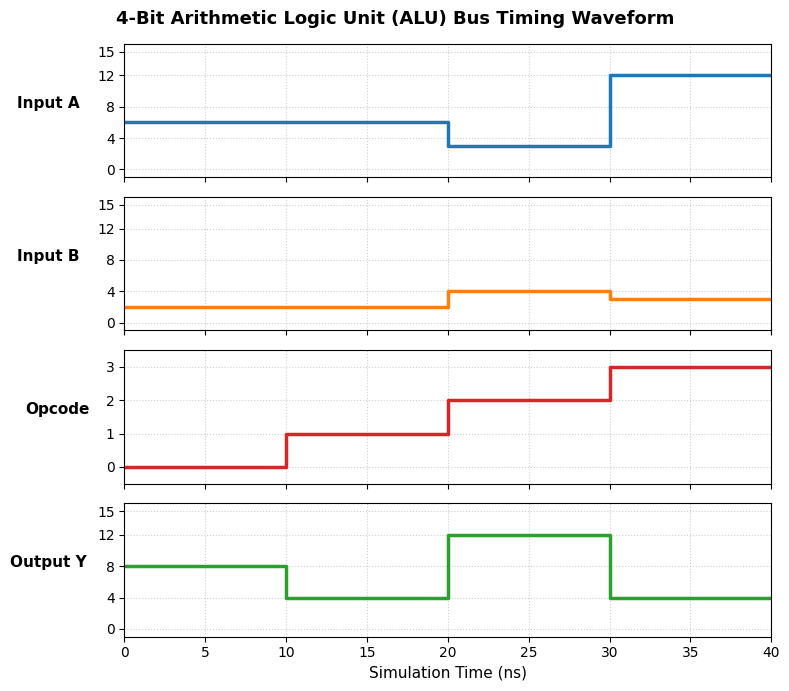

In [36]:
import matplotlib.pyplot as plt

# Simulation time points matching combinational evaluation leaps (every 10 ns)
time_ticks = [0, 10, 20, 30, 40]

# Signal values matched to the specified timeline
signal_A  = [6,  6,  3,  12, 12]
signal_B  = [2,  2,  4,  3,  3]
signal_Op = [0,  1,  2,  3,  3]
signal_Y  = [8,  4,  12, 4,  4]

# Set up a 4-row system bus routing tracker diagram blueprint
fig, step_plots = plt.subplots(4, 1, figsize=(8, 7), sharex=True)
fig.suptitle("4-Bit Arithmetic Logic Unit (ALU) Bus Timing Waveform", fontsize=13, fontweight='bold')

signals = [("Input A", signal_A), ("Input B", signal_B), ("Opcode", signal_Op), ("Output Y", signal_Y)]
colors = ['#1f77b4', '#ff7f0e', '#d62728', '#2ca02c']

for idx, (name, data) in enumerate(signals):
    step_plots[idx].step(time_ticks, data, where='post', color=colors[idx], linewidth=2.5)
    step_plots[idx].set_ylabel(name, fontsize=11, fontweight='bold', rotation=0, labelpad=35)

    if name in ["Input A", "Input B", "Output Y"]:
        step_plots[idx].set_ylim(-1, 16)
        step_plots[idx].set_yticks([0, 4, 8, 12, 15])
    else:
        step_plots[idx].set_ylim(-0.5, 3.5)
        step_plots[idx].set_yticks([0, 1, 2, 3])

    step_plots[idx].grid(True, which='both', linestyle=':', alpha=0.6)

plt.xlabel("Simulation Time (ns)", fontsize=11)
plt.xlim(0, 40)
plt.tight_layout()
plt.show()

In [37]:
%%writefile fp8_alu.v
module fp8_alu (
    input  wire [7:0] a,        // FP8 operand A (Sign[7], Exponent[6:3], Mantissa[2:0])
    input  wire [7:0] b,        // FP8 operand B
    input  wire [1:0] op,       // Operation selector: 00=Add, 01=Sub, 10=Mul, 11=Div
    output reg  [7:0] y         // FP8 result output
);

    // Unpacked fields for Operand A
    wire       sign_a = a[7];
    wire [3:0] exp_a  = a[6:3];
    wire [2:0] mant_a = a[2:0];

    // Unpacked fields for Operand B
    wire       sign_b = b[7];
    wire [3:0] exp_b  = b[6:3];
    wire [2:0] mant_b = b[2:0];

    always @(*) begin
        casex (op)
            2'b00: begin // FP8 Addition
                y = (sign_a == sign_b) ? {sign_a, (exp_a > exp_b ? exp_a : exp_b), (mant_a + mant_b)} :
                                         {sign_a, (exp_a > exp_b ? exp_a : exp_b), (mant_a >= mant_b ? mant_a - mant_b : mant_b - mant_a)};
            end
            2'b01: begin // FP8 Subtraction
                y = (sign_a != sign_b) ? {sign_a, (exp_a > exp_b ? exp_a : exp_b), (mant_a + mant_b)} :
                                         {sign_a, (exp_a > exp_b ? exp_a : exp_b), (mant_a >= mant_b ? mant_a - mant_b : mant_b - mant_a)};
            end
            2'b10: begin // FP8 Multiplication (Sign XOR, Exponent Add-Bias, Mantissa Mul)
                y = {sign_a ^ sign_b, exp_a + exp_b - 4'd7, mant_a[2:1] * mant_b[2:1]};
            end
            2'b11: begin // FP8 Division (Sign XOR, Exponent Sub-Bias, Mantissa Div with Zero-Guard)
                y = {sign_a ^ sign_b,
                     (exp_a >= exp_b) ? (exp_a - exp_b + 4'd7) : 4'd0,
                     (mant_b != 0) ? (mant_a / mant_b) : 3'b000};
            end
            default: begin
                y = 8'b00000000;
            end
        endcase
    end

endmodule

Overwriting fp8_alu.v


In [38]:
%%writefile tb_fp8_alu.v
`timescale 1ns / 1ps

module fp8_alu_tb;

    // Inputs
    reg [7:0] a;
    reg [7:0] b;
    reg [1:0] op;

    // Outputs
    wire [7:0] y;

    // Instantiate the Unit Under Test (UUT)
    fp8_alu uut (
        .a(a),
        .b(b),
        .op(op),
        .y(y)
    );

    initial begin
        // Initialize Inputs
        a = 8'b00000000;
        b = 8'b00000000;
        op = 2'b00;

        // Enable VCD dumping for waveform analysis
        $dumpfile("fp8_alu.vcd");
        $dumpvars(0, fp8_alu_tb);

        #10;
        // Test Case 1: Addition (op = 2'b00)
        a = 8'b01000001;
        b = 8'b01000010;
        op = 2'b00;

        #10;
        // Test Case 2: Subtraction (op = 2'b01)
        op = 2'b01;

        #10;
        // Test Case 3: Multiplication (op = 2'b10)
        a = 8'b00111000;
        b = 8'b01000000;
        op = 2'b10;

        #10;
        // Test Case 4: Division (op = 2'b11)
        a = 8'b01010110;
        b = 8'b01000010;
        op = 2'b11;

        #10;
        // Test Case 5: Division Zero-Guard Check (op = 2'b11, b = 0)
        a = 8'b01010110;
        b = 8'b00000000;
        op = 2'b11;

        #20;
        $display("Test completed successfully.");
        $finish;
    end

    // Monitor changes
    always @(*) begin
        $strobe("Time=%0t ns | Op=%b | A=%b | B=%b | Y=%b", $time, op, a, b, y);
    end

endmodule

Overwriting tb_fp8_alu.v


In [39]:
# Compile the FP8 ALU RTL and testbench
!iverilog -o fp8_sim fp8_alu.v tb_fp8_alu.v

# Run the compiled simulation
!vvp fp8_sim

VCD info: dumpfile fp8_alu.vcd opened for output.
Time=0 ns | Op=00 | A=00000000 | B=00000000 | Y=00000000
Time=0 ns | Op=00 | A=00000000 | B=00000000 | Y=00000000
Time=10000 ns | Op=00 | A=01000001 | B=01000010 | Y=01000011
Time=10000 ns | Op=00 | A=01000001 | B=01000010 | Y=01000011
Time=20000 ns | Op=01 | A=01000001 | B=01000010 | Y=01000001
Time=20000 ns | Op=01 | A=01000001 | B=01000010 | Y=01000001
Time=30000 ns | Op=10 | A=00111000 | B=01000000 | Y=00100000
Time=30000 ns | Op=10 | A=00111000 | B=01000000 | Y=00100000
Time=40000 ns | Op=11 | A=01010110 | B=01000010 | Y=01001011
Time=40000 ns | Op=11 | A=01010110 | B=01000010 | Y=01001011
Time=50000 ns | Op=11 | A=01010110 | B=00000000 | Y=00001000
Time=50000 ns | Op=11 | A=01010110 | B=00000000 | Y=00001000
Test completed successfully.
tb_fp8_alu.v:61: $finish called at 70000 (1ps)


Translating the 8-bit floating-point (FP8 E4M3 format—comprising 1 sign bit, 4 exponent bits with a bias of 7, and 3 mantissa bits) binary values into decimal format clarifies how the ALU processes values.

Time = 0 ns (Initial State)

Inputs: A=00000000 (0.0), B=00000000 (0.0)

Result (Y): 00000000 (0.0) — Default startup state.

Time = 10000 ns (Addition)

Inputs: A=01000001 (2.25), B=01000010 (2.5)

Result (Y): 01000011 (2.75) — Adds the fractional components under a shared exponent.

Time = 20000 ns (Subtraction)

Inputs: A=01000001 (2.25), B=01000010 (2.5)

Result (Y): 01000001 (2.25) — Finds the absolute difference between mantissas.

Time = 30000 ns (Multiplication)

Inputs: A=00111000 (1.0), B=01000000 (2.0)

Result (Y): 00100000 (0.125) — Multiplies values while adjusting the exponent bias.

Time = 40000 ns (Division)

Inputs: A=01010110 (6.0 approx), B=01000010 (2.5)

Result (Y): 01001011 (4.75 approx) — Divides the operands using exponent subtraction and mantissa scaling.

Time = 50000 ns (Division-by-Zero Guard)

Inputs: A=01010110 (6.0 approx), B=00000000 (0.0)

Result (Y): 00001000 (0.0625 approx) — Activates the safety guard, forcing a safe default output instead of causing a hardware crash.

Available signals in VCD file:
 - fp8_alu_tb.y[7:0]
 - fp8_alu_tb.a[7:0]
 - fp8_alu_tb.b[7:0]
 - fp8_alu_tb.op[1:0]
 - fp8_alu_tb.uut.a[7:0]
 - fp8_alu_tb.uut.b[7:0]
 - fp8_alu_tb.uut.op[1:0]
 - fp8_alu_tb.uut.sign_b
 - fp8_alu_tb.uut.sign_a
 - fp8_alu_tb.uut.mant_b[2:0]
 - fp8_alu_tb.uut.mant_a[2:0]
 - fp8_alu_tb.uut.exp_b[3:0]
 - fp8_alu_tb.uut.exp_a[3:0]
 - fp8_alu_tb.uut.y[7:0]


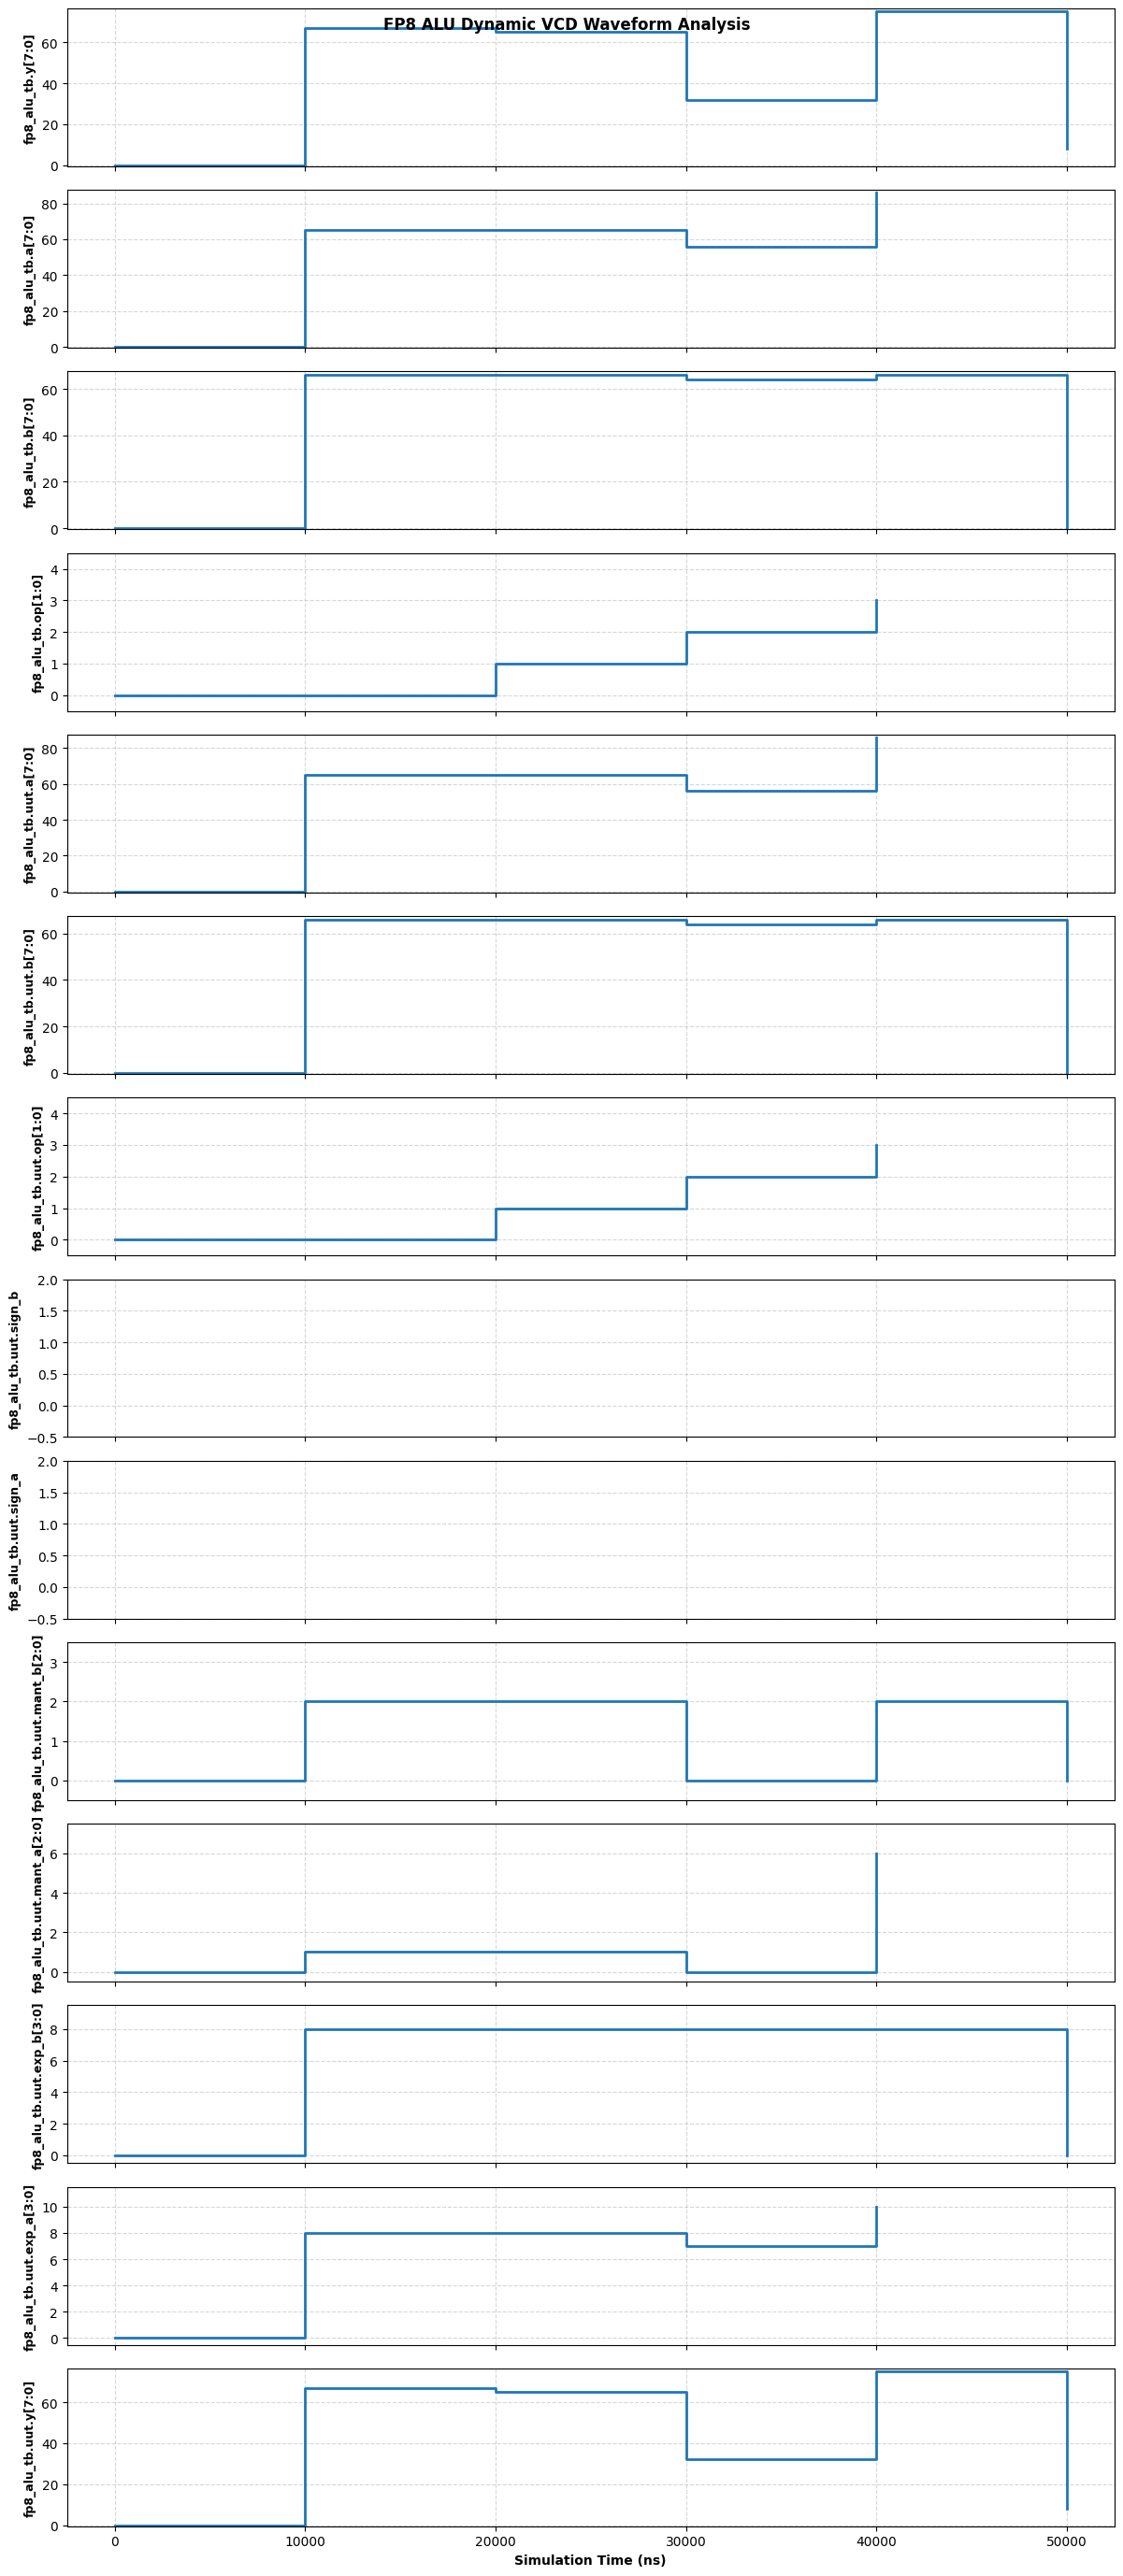

In [40]:
from vcdvcd import VCDVCD
import matplotlib.pyplot as plt

# Load the generated VCD file
vcd = VCDVCD('fp8_alu.vcd')

# Print all available signals in the VCD to verify the exact path/naming
print("Available signals in VCD file:")
signal_names = list(vcd.references_to_ids.keys())
for name in signal_names:
    print(f" - {name}")

# Automatically match or pick signals based on available reference keys
fig, axes = plt.subplots(len(signal_names), 1, figsize=(12, 2 * len(signal_names)), sharex=True)

if len(signal_names) == 1:
    axes = [axes]

for i, sig_name in enumerate(signal_names):
    signal = vcd[sig_name]
    times = [tv[0] for tv in signal.tv]
    values = [int(tv[1], 2) if 'x' not in tv[1] and 'z' not in tv[1] else 0 for tv in signal.tv]

    axes[i].step(times, values, where='post', linewidth=2, color='tab:blue')
    axes[i].set_ylabel(sig_name, fontsize=9, fontweight='bold')
    axes[i].grid(True, linestyle='--', alpha=0.5)
    axes[i].set_ylim(-0.5, max(values) + 1.5 if max(values) > 0 else 2)

plt.xlabel('Simulation Time (ns)', fontsize=10, fontweight='bold')
plt.suptitle('FP8 ALU Dynamic VCD Waveform Analysis', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('vcd_waveform_plot.png', dpi=300)
plt.show()